
# مشروع: سرطان الغدة الدرقية — تصنيف ثنائي ومتعدد الفئات (UCI)
**إعداد:** تنظيف البيانات → الاستكشاف → النمذجة (Logistic/RandomForest) → التقييم (Accuracy/Precision/Recall/F1/ROC-AUC) → التفسير (Coefficients/Importances)  
**الأهداف:**
- **Binary Classification**: التنبؤ بعودة المرض `Recurred` (Yes/No).
- **Multi-class Classification**: التنبؤ بمرحلة المرض `Stage` (I, II, III, IV) — أو عمود متعدد آخر مثل `Risk` إن وُجد.

---

## 🧭 فهرس
1. [تحميل المكتبات والبيانات](#load)
2. [استكشاف البيانات (شكل الجدول والأعمدة)](#eda)
3. [القيم المفقودة + المكررة + القيم الشاذة (Nulls/Duplicates/Outliers)](#clean)
4. [رسوم استكشافية للتوزيعات](#plots)
5. [تصنيف ثنائي — Recurred (Yes/No)](#binary)
   - تجهيز السمات، التقسيم، النمذجة (Logistic/RandomForest)، التقييم، ROC/CM
   - تفسير الميزات (Coefficients/Importances)
6. [تصنيف متعدد — Stage (I/II/III/IV)](#multi)
   - تجهيز السمات، التقسيم، النمذجة (Multinomial Logistic/RandomForest)، التقييم، ROC/CM
   - تفسير الميزات
7. [مقارنة ختامية + إجابات جاهزة للمناقشة](#qa)


## 1) تحميل المكتبات والبيانات  {#load}

In [28]:
import pandas as pd

import os, re, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from typing import List, Tuple, Dict

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier

PATH = r"C:\Users\Raidan\Desktop\DM_END\Thyroid_Diff.csv"
assert os.path.exists(PATH), f"⚠️ الملف غير موجود: {PATH}"
df_raw = pd.read_csv(PATH)
df = df_raw.copy()




## 2) استكشاف البيانات (شكل الجدول والأعمدة)  {#eda}

In [29]:
import os
import pandas as pd
import numpy as np

# ========= 1) تحميل الملف وتحسين العرض =========
PATH = r"C:\Users\Raidan\Desktop\DM_END\Thyroid_Diff.csv"
assert os.path.exists(PATH), "⚠️ الملف غير موجود. عدّل المسار PATH."

pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 2000)

df = pd.read_csv(PATH)
print("الأعمدة:", list(df.columns))
print("الأنواع:", df.dtypes)
print("الحجم:", df.shape)

# ========= 2) عرض الجدول ثم رسالة التحميل + الشكل =========
display(df.head(10))            # أول جدول
print("✅ تم التحميل")
print("الشكل:", df.shape)       # (صفوف, أعمدة)

# ========= 3) أدوات تنسيق (بدون تكرار، عربي+إنجليزي) =========
ar_name = {
    "Age": "العمر", "Gender": "الجنس", "Smoking": "التدخين",
    "Hx Smoking": "تاريخ التدخين", "Hx Radiothreapy": "تاريخ العلاج الإشعاعي",
    "Thyroid Function": "وظيفة الغدة الدرقية", "Physical Examination": "الفحص السريري",
    "Adenopathy": "حالة العقد اللمفاوية", "Pathology": "نوع النسيج",
    "Focality": "البؤرية", "Risk": "مستوى الخطورة",
    "T": "T — حجم/امتداد الورم", "N": "N — إصابة العقد", "M": "M — النقائل البعيدة",
    "Stage": "المرحلة المجمّعة", "Response": "الاستجابة للعلاج", "Recurred": "عودة المرض (الهدف الثنائي)"
}

comments = {
    "Age":"لماذا مهم؟ كبار السن قد ترتفع لديهم المخاطر.",
    "Gender":"لماذا مهم؟ سرطان الغدة يظهر أكثر لدى الإناث عادةً.",
    "Smoking":"تعكس سلوكًا صحياً قد يرتبط بالمضاعفات.",
    "Hx Smoking":"التاريخ المرضي للتدخين قد يؤثر على الإنذار.",
    "Hx Radiothreapy":"تعرض سابق للإشعاع قد يرفع مخاطر معينة.",
    "Thyroid Function":"الحالة الهرمونية وقت التشخيص قد ترتبط بشدة المرض.",
    "Physical Examination":"تفاصيل شكل/عدد العُقد في الغدة.",
    "Adenopathy":"تورّم/انتشار بالعقد اللمفاوية يرتبط بالمرحلة.",
    "Pathology":"نوع الورم تحت المجهر قد يرتبط بعودة المرض.",
    "Focality":"تعدد البؤر قد يرفع احتمالية التكرار.",
    "Risk":"تقييم سريري عام لمستوى الخطورة.",
    "T":"جزء من TNM — يصف حجم/امتداد الورم.",
    "N":"جزء من TNM — يصف إصابة العقد.",
    "M":"جزء من TNM — يصف وجود نقائل بعيدة.",
    "Stage":"مشتق من TNM — مرحلة المرض النهائية.",
    "Response":"بعد العلاج — استخدامه لتنبؤ العودة قد يسبب تسريب.",
    "Recurred":"هدف ثنائي: Yes/No — عودة المرض."
}

def title_bilingual(col):
    return f"🔹 {ar_name.get(col, col)} — ({col})"

def neat_counts(series: pd.Series, max_rows=15) -> pd.DataFrame:
    """ value_counts نظيف: value | count | percent (بدون تكرار اسم السلسلة) """
    vc = series.value_counts(dropna=False)
    if len(vc) > max_rows:
        vc = vc.head(max_rows)
    total = int(len(series))
    out = (
        vc.rename_axis("value")
          .to_frame("count")
          .assign(percent=lambda x: (x["count"]/total*100).round(1))
    )
    return out

# ========= 4) الملخص بالعربي + التوزيعات (يبدأ بـ Age ثم الإحصائيات) =========
print("\n🔎 ملخص الأعمدة بالعربي + التوزيعات")
print("-----------------------------------")

# أولاً: Age مع "ليش مهم" + التوزيع
if "Age" in df.columns:
    col = "Age"
    print(title_bilingual(col))
    if comments.get(col): print("   ", comments[col])
    print("   التوزيع (أعلى القيم):")
    print(neat_counts(df[col]).to_string())
    print()  # سطر فاصل

    # مباشرة بعد Age: جدول الإحصائيات الرقمية كما طلبت
    desc = (df[[col]].describe()
            .rename(index={"25%":"25%","50%":"50%","75%":"75%"}))
    display(desc)

# ثم: بقية الأعمدة بنفس التنسيق (بدون تكرار)
for col in df.columns:
    if col == "Age":   # تم عرضه فوق مع الإحصائيات
        continue
    print()
    print(title_bilingual(col))
    if comments.get(col): print("   ", comments[col])
    print("   التوزيع (أعلى القيم):")
    print(neat_counts(df[col]).to_string())

# ========= 5) الملخص العام في النهاية =========
print("\n" + "-"*40)
print("📦 ملخص عام")
print("-----------------------------")
print(f"الشكل: {df.shape[0]} صف × {df.shape[1]} عمود")
print(f"المفقودات (مجموع الخلايا الناقصة): {int(df.isna().sum().sum())}")
print(f"الصفوف المكرّرة: {int(df.duplicated().sum())}")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in df.columns if c not in num_cols]
print(f"🧮 الأعمدة الرقمية: {num_cols}")
print(f"🔤 الأعمدة الفئوية/النصية: {cat_cols}")

# (اختياري) وصف رقمي مجمّع لو أضفت أعمدة رقمية لاحقاً غير Age
if num_cols:
    print("\n📊 ملخص إحصائي للأعمدة الرقمية:")
    display(df[num_cols].describe().T)


    # نجمع صف للمخطط الملخّص
# === 1) تجهيز تجميع "بطاقة تعريف" لكل عمود ===
summary_rows = []

def arabic_name(col: str) -> str:
    return ar_name.get(col, col)

# === 2) عرض ملخص الأعمدة + جمع المعلومات للجدول ===
print("\n🔎 ملخص الأعمدة بالعربي + التوزيعات")
print("-----------------------------------")

# أولًا: عمود Age كما في تنسيقك الحالي
if "Age" in df.columns:
    col = "Age"
    print(f"🔹 {arabic_name(col)} — ({col})")
    cmt = comments.get(col, "")
    if cmt: print("   ", cmt)
    print("   التوزيع (أعلى القيم):")
    print(neat_counts(df[col]).to_string())
    print()
    display(df[[col]].describe().rename(index={"25%":"25%","50%":"50%","75%":"75%"}))
    # نجمع سطر لجدول الملخص
    summary_rows.append({
        "العمود": col,
        "الاسم العربي": arabic_name(col),
        "عدد القيم الفريدة": df[col].nunique(),
        "ملاحظة": cmt
    })

# بقية الأعمدة
for col in df.columns:
    if col == "Age":
        continue
    print()
    print(f"🔹 {arabic_name(col)} — ({col})")
    cmt = comments.get(col, "")
    if cmt: print("   ", cmt)
    print("   التوزيع (أعلى القيم):")
    print(neat_counts(df[col]).to_string())

    # نجمع سطر لجدول الملخص
    summary_rows.append({
        "العمود": col,
        "الاسم العربي": arabic_name(col),
        "عدد القيم الفريدة": df[col].nunique(),
        "ملاحظة": cmt
    })

# === 3) إنشاء جدول الملخص وعرضه مرة واحدة (بدون تكرارات) ===
summary_meta = pd.DataFrame(summary_rows)[["العمود","الاسم العربي","عدد القيم الفريدة","ملاحظة"]]
display(summary_meta)

# === 4) تحذيرات التسريب المحتملة ===
leak_warnings = []
if set(["Response","Recurred"]).issubset(df.columns):
    leak_warnings.append("⚠️ عند التنبؤ بـ Recurred يُفضّل استبعاد Response لأنه يأتي بعد العلاج وقد يسرّب المعلومة.")
if set(["T","N","M","Stage"]).issubset(df.columns):
    leak_warnings.append("⚠️ عند التنبؤ بـ Stage استخدام T/N/M يجعل المهمة شبه تحويل مباشر (أداء عالي لكن قيمة علمية أقل).")

if leak_warnings:
    print("🚨 تحذيرات تسريب محتملة:")
    for w in leak_warnings:
        print(" -", w)
else:
    print("✅ لا توجد تحذيرات تسريب واضحة بحسب الأعمدة الحالية.")


الأعمدة: ['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']
الأنواع: Age                      int64
Gender                  object
Smoking                 object
Hx Smoking              object
Hx Radiothreapy         object
Thyroid Function        object
Physical Examination    object
Adenopathy              object
Pathology               object
Focality                object
Risk                    object
T                       object
N                       object
M                       object
Stage                   object
Response                object
Recurred                object
dtype: object
الحجم: (383, 17)


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No
5,52,M,Yes,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Indeterminate,No
6,41,F,No,Yes,No,Clinical Hyperthyroidism,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
7,46,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
8,51,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
9,40,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No


✅ تم التحميل
الشكل: (383, 17)

🔎 ملخص الأعمدة بالعربي + التوزيعات
-----------------------------------
🔹 العمر — (Age)
    لماذا مهم؟ كبار السن قد ترتفع لديهم المخاطر.
   التوزيع (أعلى القيم):
       count  percent
value                
31        22      5.7
27        13      3.4
40        12      3.1
26        12      3.1
28        12      3.1
35        12      3.1
30        12      3.1
33        12      3.1
34        11      2.9
29        11      2.9
38        11      2.9
32        10      2.6
51        10      2.6
62        10      2.6
37        10      2.6



,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000



🔹 الجنس — (Gender)
    لماذا مهم؟ سرطان الغدة يظهر أكثر لدى الإناث عادةً.
   التوزيع (أعلى القيم):
       count  percent
value                
F        312     81.5
M         71     18.5

🔹 التدخين — (Smoking)
    تعكس سلوكًا صحياً قد يرتبط بالمضاعفات.
   التوزيع (أعلى القيم):
       count  percent
value                
No       334     87.2
Yes       49     12.8

🔹 تاريخ التدخين — (Hx Smoking)
    التاريخ المرضي للتدخين قد يؤثر على الإنذار.
   التوزيع (أعلى القيم):
       count  percent
value                
No       355     92.7
Yes       28      7.3

🔹 تاريخ العلاج الإشعاعي — (Hx Radiothreapy)
    تعرض سابق للإشعاع قد يرفع مخاطر معينة.
   التوزيع (أعلى القيم):
       count  percent
value                
No       376     98.2
Yes        7      1.8

🔹 وظيفة الغدة الدرقية — (Thyroid Function)
    الحالة الهرمونية وقت التشخيص قد ترتبط بشدة المرض.
   التوزيع (أعلى القيم):
                             count  percent
value                                      
Euthyroid                   

...


🔎 ملخص الأعمدة بالعربي + التوزيعات
-----------------------------------
🔹 العمر — (Age)
    لماذا مهم؟ كبار السن قد ترتفع لديهم المخاطر.
   التوزيع (أعلى القيم):
       count  percent
value                
31        22      5.7
27        13      3.4
40        12      3.1
26        12      3.1
28        12      3.1
35        12      3.1
30        12      3.1
33        12      3.1
34        11      2.9
29        11      2.9
38        11      2.9
32        10      2.6
51        10      2.6
62        10      2.6
37        10      2.6



,Age
count,383.000000
mean,40.866841
std,15.134494
min,15.000000
25%,29.000000
50%,37.000000
75%,51.000000
max,82.000000



🔹 الجنس — (Gender)
    لماذا مهم؟ سرطان الغدة يظهر أكثر لدى الإناث عادةً.
   التوزيع (أعلى القيم):
       count  percent
value                
F        312     81.5
M         71     18.5

🔹 التدخين — (Smoking)
    تعكس سلوكًا صحياً قد يرتبط بالمضاعفات.
   التوزيع (أعلى القيم):
       count  percent
value                
No       334     87.2
Yes       49     12.8

🔹 تاريخ التدخين — (Hx Smoking)
    التاريخ المرضي للتدخين قد يؤثر على الإنذار.
   التوزيع (أعلى القيم):
       count  percent
value                
No       355     92.7
Yes       28      7.3

🔹 تاريخ العلاج الإشعاعي — (Hx Radiothreapy)
    تعرض سابق للإشعاع قد يرفع مخاطر معينة.
   التوزيع (أعلى القيم):
       count  percent
value                
No       376     98.2
Yes        7      1.8

🔹 وظيفة الغدة الدرقية — (Thyroid Function)
    الحالة الهرمونية وقت التشخيص قد ترتبط بشدة المرض.
   التوزيع (أعلى القيم):
                             count  percent
value                                      
Euthyroid                   

,العمود,الاسم العربي,عدد القيم الفريدة,ملاحظة
0,Age,العمر,65,لماذا مهم؟ كبار السن قد ترتفع لديهم المخاطر.
1,Gender,الجنس,2,لماذا مهم؟ سرطان الغدة يظهر أكثر لدى الإناث عا...
2,Smoking,التدخين,2,تعكس سلوكًا صحياً قد يرتبط بالمضاعفات.
3,Hx Smoking,تاريخ التدخين,2,التاريخ المرضي للتدخين قد يؤثر على الإنذار.
4,Hx Radiothreapy,تاريخ العلاج الإشعاعي,2,تعرض سابق للإشعاع قد يرفع مخاطر معينة.
5,Thyroid Function,وظيفة الغدة الدرقية,5,الحالة الهرمونية وقت التشخيص قد ترتبط بشدة المرض.
6,Physical Examination,الفحص السريري,5,تفاصيل شكل/عدد العُقد في الغدة.
7,Adenopathy,حالة العقد اللمفاوية,6,تورّم/انتشار بالعقد اللمفاوية يرتبط بالمرحلة.
8,Pathology,نوع النسيج,4,نوع الورم تحت المجهر قد يرتبط بعودة المرض.
9,Focality,البؤرية,2,تعدد البؤر قد يرفع احتمالية التكرار.


🚨 تحذيرات تسريب محتملة:
 - ⚠️ عند التنبؤ بـ Recurred يُفضّل استبعاد Response لأنه يأتي بعد العلاج وقد يسرّب المعلومة.
 - ⚠️ عند التنبؤ بـ Stage استخدام T/N/M يجعل المهمة شبه تحويل مباشر (أداء عالي لكن قيمة علمية أقل).


## 3) القيم المفقودة + المكررة + القيم الشاذة  {#clean}

In [30]:
# --- Missing values
missing_cnt = df.isna().sum().sort_values(ascending=False) 
# يحسب عدد القيم الناقصة (NaN) في كل عمود، ويرتّب الأعمدة تنازليًا (الأكثر نقصًا أولاً)

missing_pct = (df.isna().mean()*100).round(2).sort_values(ascending=False) 
# يحسب نسبة القيم الناقصة (من 0% إلى 100%) في كل عمود، ثم يقرّبها لـ خانتين عشريتين ويرتبها

missing_summary = pd.DataFrame({"missing_count": missing_cnt, "missing_%": missing_pct})
# يجمع النتائج في جدول DataFrame فيه عمودين: عدد القيم الناقصة + النسبة %

display(missing_summary)  
# يعرض الجدول بشكل مرتب في Jupyter
# --- Duplicates
dups_count = df.duplicated().sum()  
# يحسب عدد الصفوف المكررة (التي لها نفس القيم في كل الأعمدة)

print("عدد الصفوف المكررة:", dups_count)  
# يطبع عدد الصفوف المكررة

if dups_count > 0:  
    df = df.drop_duplicates().reset_index(drop=True)  
    # لو فيه مكررات: يحذفها ويرجع الفهرسة (index) من 0 من جديد
    
    print("تم حذف الصفوف المكررة. الشكل الجديد:", df.shape)  
    # يطبع الشكل الجديد للبيانات (عدد الصفوف × الأعمدة) بعد الحذف

# --- تحديد الأعمدة الرقمية/الفئوية
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()  
# يختار الأعمدة الرقمية (int/float) ويحوّل أسماءها إلى قائمة

cat_cols = [c for c in df.columns if c not in num_cols]  
# الأعمدة الباقية (غير رقمية) يعتبرها فئوية/نصية ويحطها في قائمة ثانية
# --- تعبئة المفقودات
for c in num_cols:  
    if df[c].isna().any():  
        # يمر على كل عمود رقمي، ويتأكد لو فيه أي NaN
        
        df[c] = df[c].fillna(df[c].median())  
        # يعبّي القيم الناقصة بالقيمة الوسيطة (median)

for c in cat_cols:  
    if df[c].isna().any():  
        # يمر على كل عمود فئوي، ويتأكد لو فيه NaN
        
        mode_val = df[c].mode(dropna=True)  
        # يحسب القيمة الأكثر شيوعًا (mode) مع تجاهل القيم الناقصة
        
        df[c] = df[c].fillna(mode_val.iloc[0] if not mode_val.empty else "Unknown")  
        # لو وجد mode → يعبّي به، ولو ما فيه قيم على الإطلاق يحط "Unknown"
# --- Outliers IQR capping على الأعمدة الرقمية
def iqr_cap(df_in: pd.DataFrame, cols: List[str]):
    caps = {}  
    for c in cols:  
        if df_in[c].dtype.kind in "biufc":  
            # يمر على الأعمدة الرقمية فقط
            
            q1, q3 = df_in[c].quantile(0.25), df_in[c].quantile(0.75)  
            # يحسب الربع الأول (Q1=25%) والربع الثالث (Q3=75%)
            
            iqr = q3 - q1  
            # يحسب IQR (المسافة بين الربعين)
            
            if iqr == 0: 
                continue  
            # لو IQR = 0 يعني كل القيم متساوية، يتخطى العمود
            
            lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr  
            # يحسب الحدود الطبيعية (Lower, Upper) حسب قاعدة Tukey
            
            before = ((df_in[c] < lower) | (df_in[c] > upper)).sum()  
            # يحسب كم Outliers (خارج النطاق) قبل التعديل
            
            df_in[c] = np.clip(df_in[c], lower, upper)  
            # يقصّ القيم: أي قيمة أصغر من lower يجعلها = lower، وأي قيمة أكبر من upper يجعلها = upper
            
            after = ((df_in[c] < lower) | (df_in[c] > upper)).sum()  
            # يحسب كم Outliers بعد التعديل (عادةً = 0)
            
            caps[c] = {"lower_cap": float(lower), "upper_cap": float(upper),
                       "outliers_before": int(before), "outliers_after": int(after)}  
            # يخزن النتائج في dict: الحدود + عدد القيم الشاذة قبل/بعد
    
    return pd.DataFrame(caps).T  
    # يرجّع النتائج في جدول DataFrame (كل صف = عمود رقمي، والأعمدة = الحدود+العدادات)

caps_df = iqr_cap(df, num_cols)  
# يطبق الدالة على الأعمدة الرقمية كلها

display(caps_df if caps_df is not None else pd.DataFrame())  
# يعرض جدول Outliers (لو فيه)




,missing_count,missing_%
Age,0,0.0
Focality,0,0.0
Response,0,0.0
Stage,0,0.0
M,0,0.0
N,0,0.0
T,0,0.0
Risk,0,0.0
Pathology,0,0.0
Gender,0,0.0


عدد الصفوف المكررة: 19
تم حذف الصفوف المكررة. الشكل الجديد: (364, 17)


,lower_cap,upper_cap,outliers_before,outliers_after
Age,-3.0,85.0,0.0,0.0


## 4) رسوم استكشافية للتوزيعات  {#plots}

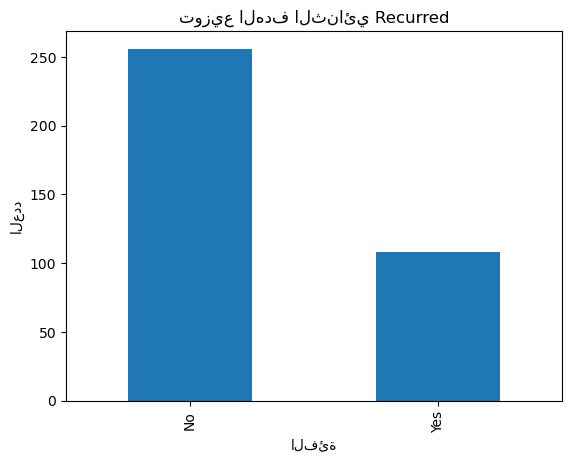

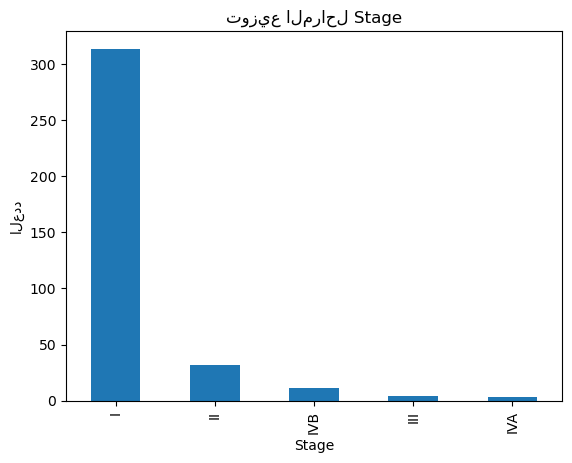

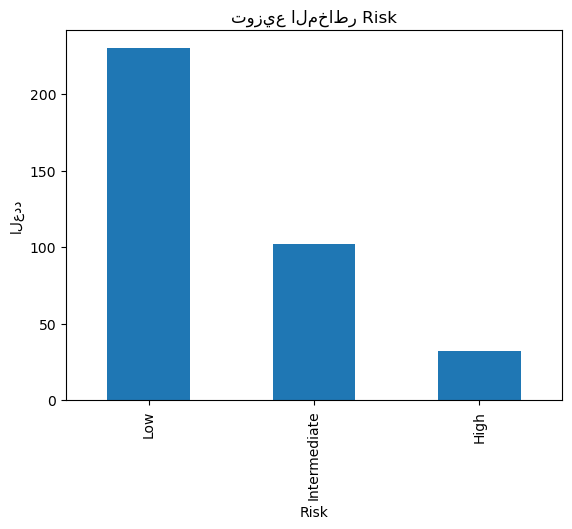

In [31]:

plt.figure(); df["Recurred"].value_counts().plot(kind="bar"); plt.title("توزيع الهدف الثنائي Recurred"); plt.xlabel("الفئة"); plt.ylabel("العدد"); plt.show()
if "Stage" in df.columns:
    plt.figure(); df["Stage"].value_counts().plot(kind="bar"); plt.title("توزيع المراحل Stage"); plt.xlabel("Stage"); plt.ylabel("العدد"); plt.show()
if "Risk" in df.columns:
    plt.figure(); df["Risk"].value_counts().plot(kind="bar"); plt.title("توزيع المخاطر Risk"); plt.xlabel("Risk"); plt.ylabel("العدد"); plt.show()


## 5) تصنيف ثنائي — Recurred (Yes/No)  {#binary}

✅ تجهيز البيانات:
- الهدف y_bin (0=No, 1=Yes) | عدد العينات = 364
- عدد الخصائص = 16 | رقمية: 1 | فئوية: 15

🔀 التقسيم Train/Test:
- Train: 291 عينة
- Test : 73 عينة  ← هذا الرقم ستراه كـ support=73 في التقرير (على حسب بياناتك)

🏋️‍♂️ تم تدريب النموذجين: Logistic & RandomForest



,model,accuracy_train,precision_train,recall_train,f1_train,accuracy_test,precision_test,recall_test,f1_test,roc_auc_test
0,Logistic (Binary),0.979381,0.965116,0.965116,0.965116,0.931507,0.84,0.954545,0.893617,0.975045
1,RandomForest (Binary),1.0,1.0,1.0,1.0,0.945205,0.875,0.954545,0.913043,0.96836



🧾 شرح سريع للجدول أعلاه:
- accuracy_test   = نسبة التوقعات الصحيحة على الاختبار.
- precision_test  = من كل من قلت عنهم Yes، كم طلعوا Yes فعلاً.
- recall_test     = من كل الـ Yes الحقيقيين، كم اكتشفتهم.
- f1_test         = متوسط يوازن بين precision و recall.
- roc_auc_test    = كلما اقترب من 1 كان التمييز بين الفئتين أفضل.

=== تقرير التصنيف (Logistic — Binary) ===
              precision    recall  f1-score   support

           0      0.979     0.922     0.949        51
           1      0.840     0.955     0.894        22

    accuracy                          0.932        73
   macro avg      0.910     0.938     0.922        73
weighted avg      0.937     0.932     0.933        73


ملحوظة بالعربي:
- السطر 0 يمثل فئة No (المرض ما رجع).
- السطر 1 يمثل فئة Yes (المرض رجع).
- support = عدد الحالات الحقيقية لكل فئة داخل مجموعة الاختبار.
- accuracy في آخر التقرير = دقة النموذج على كل الـ  test (مثلاً 73 عينة).

=== تقرير التصنيف (RF — Binary) ===
              precision    recall  f1-sc

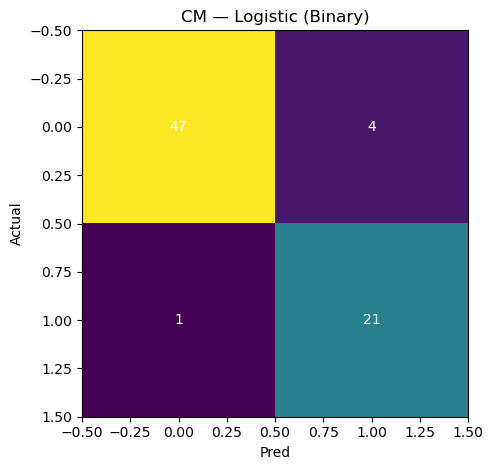


🧩 شرح مصفوفة الالتباس — Logistic
- TN (صح No)  : 47
- FP (غلط Yes): 4  ← أشخاص فعلاً No لكن تنبأنا Yes
- FN (غلط No) : 1  ← أشخاص فعلاً Yes لكن تنبأنا No
- TP (صح Yes) : 21
- المجموع     : 73 عينة اختبار


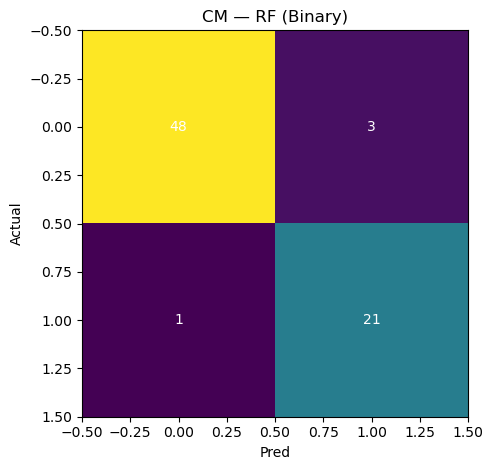


🧩 شرح مصفوفة الالتباس — RandomForest
- TN (صح No)  : 48
- FP (غلط Yes): 3  ← أشخاص فعلاً No لكن تنبأنا Yes
- FN (غلط No) : 1  ← أشخاص فعلاً Yes لكن تنبأنا No
- TP (صح Yes) : 21
- المجموع     : 73 عينة اختبار


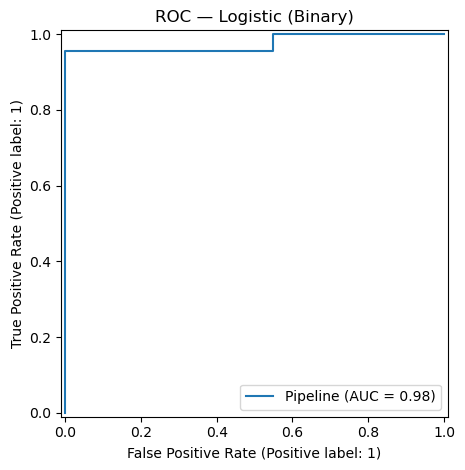

📈 ROC (Logistic): كلما اقترب الخط من الزاوية العليا اليسرى كان أفضل، وAUC في الجدول يقيس ذلك من 0 إلى 1.



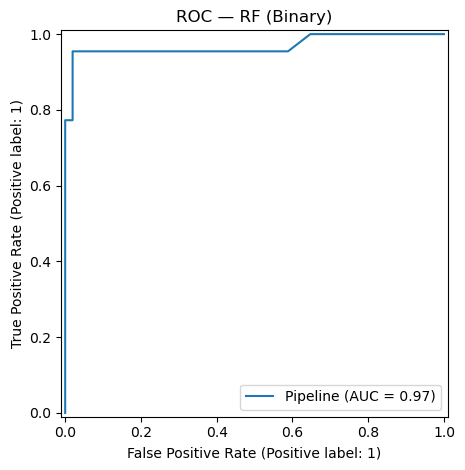

📈 ROC (RF): أيضاً قريب من الزاوية العليا اليسرى → تمييز ممتاز بين الفئتين.



In [32]:


# -------------------------------------------------------------------
# 1) تجهيز الهدف y والخصائص X
# -------------------------------------------------------------------
# الهدف: تحويل Recurred من نص ("Yes"/"No") إلى أرقام (1/0) مع تنظيف المسافات والحروف
y_bin = (df["Recurred"]
         .astype(str).str.strip().str.lower()
         .map({"no": 0, "yes": 1}))

# الخصائص: كل الأعمدة ما عدا الهدف
X_bin = df.drop(columns=["Recurred"])

# فصل الأعمدة الرقمية والفئوية (مهم للتحضير لاحقاً)
num_cols_bin = X_bin.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_bin = [c for c in X_bin.columns if c not in num_cols_bin]

print("✅ تجهيز البيانات:")
print(f"- الهدف y_bin (0=No, 1=Yes) | عدد العينات = {len(y_bin)}")
print(f"- عدد الخصائص = {X_bin.shape[1]} | رقمية: {len(num_cols_bin)} | فئوية: {len(cat_cols_bin)}\n")

# -------------------------------------------------------------------
# 2) تقسيم Train/Test
# -------------------------------------------------------------------
# stratify يحافظ على نفس نسبة الفئات في train و test
Xtr_b, Xte_b, ytr_b, yte_b = train_test_split(
    X_bin, y_bin, test_size=0.2, stratify=y_bin, random_state=42
)
print("🔀 التقسيم Train/Test:")
print(f"- Train: {Xtr_b.shape[0]} عينة")
print(f"- Test : {Xte_b.shape[0]} عينة  ← هذا الرقم ستراه كـ support=73 في التقرير (على حسب بياناتك)\n")

# -------------------------------------------------------------------
# 3) Logistic Regression (خطي) + بايبلاين التحضير
# -------------------------------------------------------------------
# للأعمدة الرقمية: StandardScaler (توحيد القياس)
# للأعمدة الفئوية: OneHotEncoder (ترميز)
pre_logit_b = ColumnTransformer([
    ("num", StandardScaler(), num_cols_bin),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_bin)
])

# البايبلاين = التحضير + المصنّف
# class_weight="balanced" يعالج عدم توازن الفئات (Yes أقل من No)
logit_b = Pipeline([
    ("prep", pre_logit_b),
    ("clf", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

# -------------------------------------------------------------------
# 4) Random Forest (غابة عشوائية) + بايبلاين التحضير
# -------------------------------------------------------------------
# الأرقام: تمر كما هي (passthrough). الفئات: OneHotEncoder
pre_rf_b = ColumnTransformer([
    ("num", "passthrough", num_cols_bin),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_bin)
])

rf_b = Pipeline([
    ("prep", pre_rf_b),
    ("clf", RandomForestClassifier(
        n_estimators=300, random_state=42, class_weight="balanced_subsample"
    ))
])

# -------------------------------------------------------------------
# 5) التدريب
# -------------------------------------------------------------------
logit_b.fit(Xtr_b, ytr_b)
rf_b.fit(Xtr_b, ytr_b)
print("🏋️‍♂️ تم تدريب النموذجين: Logistic & RandomForest\n")

# -------------------------------------------------------------------
# 6) دالة تقييم شاملة (Train/Test) + AUC
# -------------------------------------------------------------------
def eval_binary(model, Xtr, ytr, Xte, yte, name=""):
    # التنبؤ على train/test
    yhat_tr = model.predict(Xtr)
    yhat_te = model.predict(Xte)

    # احتمالات الفئة الإيجابية (لازم لـ ROC-AUC)
    proba_te = None
    try:
        proba_te = model.predict_proba(Xte)[:, 1]
    except Exception:
        pass  # بعض النماذج ما ترجع predict_proba

    # حساب المقاييس
    res = {
        "model": name,
        "accuracy_train": accuracy_score(ytr, yhat_tr),
        "precision_train": precision_score(ytr, yhat_tr, zero_division=0),
        "recall_train": recall_score(ytr, yhat_tr, zero_division=0),
        "f1_train": f1_score(ytr, yhat_tr, zero_division=0),

        "accuracy_test": accuracy_score(yte, yhat_te),
        "precision_test": precision_score(yte, yhat_te, zero_division=0),
        "recall_test": recall_score(yte, yhat_te, zero_division=0),
        "f1_test": f1_score(yte, yhat_te, zero_division=0),

        "roc_auc_test": (roc_auc_score(yte, proba_te) if proba_te is not None else np.nan)
    }
    return pd.Series(res)

# التقييم للنموذجين
res_b_log = eval_binary(logit_b, Xtr_b, ytr_b, Xte_b, yte_b, name="Logistic (Binary)")
res_b_rf  = eval_binary(rf_b,    Xtr_b, ytr_b, Xte_b, yte_b, name="RandomForest (Binary)")

# جدول النتائج
results_binary = pd.concat([res_b_log, res_b_rf], axis=1).T
display(results_binary)

print("\n🧾 شرح سريع للجدول أعلاه:")
print("- accuracy_test   = نسبة التوقعات الصحيحة على الاختبار.")
print("- precision_test  = من كل من قلت عنهم Yes، كم طلعوا Yes فعلاً.")
print("- recall_test     = من كل الـ Yes الحقيقيين، كم اكتشفتهم.")
print("- f1_test         = متوسط يوازن بين precision و recall.")
print("- roc_auc_test    = كلما اقترب من 1 كان التمييز بين الفئتين أفضل.\n")

# -------------------------------------------------------------------
# 7) تقرير التصنيف (لكل فئة على حدة)
# -------------------------------------------------------------------
print("=== تقرير التصنيف (Logistic — Binary) ===")
cr_log = classification_report(yte_b, logit_b.predict(Xte_b), digits=3)
print(cr_log)

print("\nملحوظة بالعربي:")
print("- السطر 0 يمثل فئة No (المرض ما رجع).")
print("- السطر 1 يمثل فئة Yes (المرض رجع).")
print("- support = عدد الحالات الحقيقية لكل فئة داخل مجموعة الاختبار.")
print("- accuracy في آخر التقرير = دقة النموذج على كل الـ  test (مثلاً 73 عينة).\n")

print("=== تقرير التصنيف (RF — Binary) ===")
cr_rf = classification_report(yte_b, rf_b.predict(Xte_b), digits=3)
print(cr_rf)

# -------------------------------------------------------------------
# 8) مصفوفتا الالتباس + شرح عدّي بالعربي
# -------------------------------------------------------------------
cm_log_b = confusion_matrix(yte_b, logit_b.predict(Xte_b))
cm_rf_b  = confusion_matrix(yte_b, rf_b.predict(Xte_b))

def explain_cm(cm, name=""):
    # ترتيب المصفوفة في binary:
    # [[TN, FP],
    #  [FN, TP]]
    TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    total = cm.sum()
    print(f"\n🧩 شرح مصفوفة الالتباس — {name}")
    print(f"- TN (صح No)  : {TN}")
    print(f"- FP (غلط Yes): {FP}  ← أشخاص فعلاً No لكن تنبأنا Yes")
    print(f"- FN (غلط No) : {FN}  ← أشخاص فعلاً Yes لكن تنبأنا No")
    print(f"- TP (صح Yes) : {TP}")
    print(f"- المجموع     : {total} عينة اختبار")

plt.figure()
plt.imshow(cm_log_b, cmap="viridis"); plt.title("CM — Logistic (Binary)")
plt.xlabel("Pred"); plt.ylabel("Actual")
for (i,j), v in np.ndenumerate(cm_log_b): plt.text(j,i,str(v), ha="center", va="center", color="white")
plt.tight_layout(); plt.show()
explain_cm(cm_log_b, "Logistic")

plt.figure()
plt.imshow(cm_rf_b, cmap="viridis"); plt.title("CM — RF (Binary)")
plt.xlabel("Pred"); plt.ylabel("Actual")
for (i,j), v in np.ndenumerate(cm_rf_b): plt.text(j,i,str(v), ha="center", va="center", color="white")
plt.tight_layout(); plt.show()
explain_cm(cm_rf_b, "RandomForest")

# -------------------------------------------------------------------
# 9) منحنى ROC + شرح مختصر
# -------------------------------------------------------------------
RocCurveDisplay.from_estimator(logit_b, Xte_b, yte_b)
plt.title("ROC — Logistic (Binary)"); plt.tight_layout(); plt.show()
print("📈 ROC (Logistic): كلما اقترب الخط من الزاوية العليا اليسرى كان أفضل، وAUC في الجدول يقيس ذلك من 0 إلى 1.\n")

RocCurveDisplay.from_estimator(rf_b, Xte_b, yte_b)
plt.title("ROC — RF (Binary)"); plt.tight_layout(); plt.show()
print("📈 ROC (RF): أيضاً قريب من الزاوية العليا اليسرى → تمييز ممتاز بين الفئتين.\n")


## 6) تصنيف متعدد الفئات — Stage  {#multi}

=== تقرير التصنيف (Logistic — Multi-class) ===
              precision    recall  f1-score   support

           I      0.969     0.984     0.976        63
          II      0.667     0.667     0.667         6
         III      1.000     1.000     1.000         1
         IVA      0.000     0.000     0.000         1
         IVB      0.500     0.500     0.500         2

    accuracy                          0.932        73
   macro avg      0.627     0.630     0.629        73
weighted avg      0.918     0.932     0.925        73


=== تقرير التصنيف (RF — Multi-class) ===
              precision    recall  f1-score   support

           I      0.984     0.984     0.984        63
          II      0.714     0.833     0.769         6
         III      1.000     1.000     1.000         1
         IVA      0.000     0.000     0.000         1
         IVB      0.500     0.500     0.500         2

    accuracy                          0.945        73
   macro avg      0.640     0.663     0.65

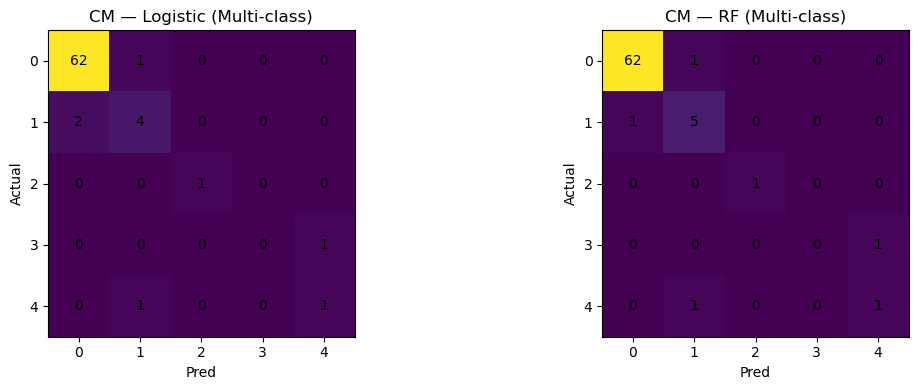


ROC-AUC (OvR) — Logistic: 0.9875 | RF: 0.9923


In [33]:

assert "Stage" in df.columns, "⚠️ عمود Stage غير موجود في الملف."
y_mc = df["Stage"].astype(str).str.strip()
X_mc = df.drop(columns=["Stage","Recurred"])  # إزالة الأهداف

num_cols_mc = X_mc.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_mc = [c for c in X_mc.columns if c not in num_cols_mc]

Xtr_m, Xte_m, ytr_m, yte_m = train_test_split(X_mc, y_mc, test_size=0.2, stratify=y_mc, random_state=42)

# Logistic (Multinomial)
pre_log_m = ColumnTransformer([
    ("num", StandardScaler(), num_cols_mc),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_mc)
])
log_m = Pipeline([("prep", pre_log_m),
                  ("clf", LogisticRegression(max_iter=3000, multi_class="multinomial"))])

# RandomForest (multi-class طبيعي)
pre_rf_m = ColumnTransformer([
    ("num", "passthrough", num_cols_mc),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_mc)
])
rf_m = Pipeline([("prep", pre_rf_m),
                 ("clf", RandomForestClassifier(n_estimators=350, random_state=42))])

log_m.fit(Xtr_m, ytr_m)
rf_m.fit(Xtr_m, ytr_m)

print("=== تقرير التصنيف (Logistic — Multi-class) ===")
print(classification_report(yte_m, log_m.predict(Xte_m), digits=3))
print("\n=== تقرير التصنيف (RF — Multi-class) ===")
print(classification_report(yte_m, rf_m.predict(Xte_m), digits=3))

# مصفوفة الالتباس (ملصقات متسقة)
labels = sorted(y_mc.unique().tolist())
cm_log_m = confusion_matrix(yte_m, log_m.predict(Xte_m), labels=labels)
cm_rf_m  = confusion_matrix(yte_m, rf_m.predict(Xte_m), labels=labels)

fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].imshow(cm_log_m); ax[0].set_title("CM — Logistic (Multi-class)")
ax[0].set_xlabel("Pred"); ax[0].set_ylabel("Actual")
for (i,j), v in np.ndenumerate(cm_log_m): ax[0].text(j,i,str(v), ha="center", va="center")

ax[1].imshow(cm_rf_m); ax[1].set_title("CM — RF (Multi-class)")
ax[1].set_xlabel("Pred"); ax[1].set_ylabel("Actual")
for (i,j), v in np.ndenumerate(cm_rf_m): ax[1].text(j,i,str(v), ha="center", va="center")
plt.tight_layout(); plt.show()

# ROC-AUC متعدد (OvR) إذا أمكن استخراج الاحتمالات
def multiclass_auc_ovr(model, X_test, y_test, labels):
    # binarize
    y_bin = label_binarize(y_test, classes=labels)
    try:
        proba = model.predict_proba(X_test)
        # إذا OneHotEncoder داخل Pipeline، predict_proba يعيد (n_samples, n_classes)
        if isinstance(proba, list):  # بعض الـ APIs تعيد قائمة
            return np.nan
        aucs = []
        # لكل فئة، نأخذ العمود الموافق
        for i in range(y_bin.shape[1]):
            aucs.append(roc_auc_score(y_bin[:, i], proba[:, i]))
        return float(np.nanmean(aucs))
    except Exception as e:
        return np.nan

auc_log_m = multiclass_auc_ovr(log_m, Xte_m, yte_m, labels)
auc_rf_m  = multiclass_auc_ovr(rf_m,  Xte_m, yte_m, labels)
print(f"\nROC-AUC (OvR) — Logistic: {auc_log_m:.4f} | RF: {auc_rf_m:.4f}")


جربت Logistic Regression (متعدد) و Random Forest لتصنيف المرضى حسب Stage (I/II/III/IVA/IVB). النتائج أظهرت أن النموذجين ممتازين مع الفئات الكبيرة (خصوصًا Stage I)، لكن أداءهم ضعيف في الفئات النادرة (مثل IVA/IVB) بسبب قلة العينات. الدقة الكلية كانت 93% للـ Logistic و 94.5% للـ RF. Random Forest أعطى نتائج أفضل قليلًا في الفئات المتوسطة، بينما Logistic كان جيد في التوازن. مشكلة رئيسية هنا هي عدم توازن البيانات بين المراحل.”